In [151]:
import os
import json
import numpy as np
import pandas as pd
import pickle





# ------------------- IMPORT SRC ------------------------------------
# src is the parent folder of notebooks, so we need to add it to sys.path to import config and utils
import sys
notebook_dir = os.getcwd() 

# Parent folder of src
project_root = os.path.abspath(os.path.join(notebook_dir, "..")) 
sys.path.append(project_root)

print("sys.path contains:", sys.path[-1])

from src.config import Config as Config  
from src.data_loader import load_data, prepare_data

cfg = Config



KAGGLE_EVAL = cfg.KAGGLE_EVAL
RANDOM_STATE = cfg.RANDOM_STATE
TASK = cfg.TASK
USE_POSTPROCESSING = cfg.USE_POSTPROCESSING
TARGET = cfg.TARGET
ID = cfg.ID
SUB_PATH = cfg.SUB_PATH
SUBMIT_PROBABILITIES = cfg.SUBMIT_PROBABILITIES
metric_name = cfg.LIB_PARAMS["lightgbm"]["metric"]

# -------------------------------------------------------



# -------------------------------
# Load Data
# -------------------------------
X_train, X_test, y_train, y_test = load_data("encoded")
# Prepare
X_train, X_test, y_train_numeric, y_test_numeric, test_ids, num_classes, int_to_label = prepare_data(
    X_train, X_test, y_train, y_test, target=cfg.TARGET, drop_id=True # ,label_map = {"A": 1, "B": 0, "C": 2}
)

# Ensure y is numpy array
y_train_numeric = np.array(y_train_numeric)
y_test_numeric = np.array(y_test_numeric) if y_test_numeric is not None else None


from src.data_splitter import DataSplitter


# ⚠️ If you don’t set folds_path, it will generate new random splits every time you call split().
splitter = DataSplitter(
    method="stratified_kfold",
    # method="repeated_stratified",
    n_splits=5,
    random_state=42,
    # n_repeats=10,
    # random_states=[42, 1337],  # multi-seed CV
    folds_path="data/folds.npy"
)

folds = list(splitter.split(X_train, y_train_numeric, reuse_folds=True, verbose=True))


task = cfg.TASK.lower()
is_regression = task == "regression"
is_binary = task == "binary"
is_multiclass = task == "multiclass"



sys.path contains: /home/ismail/x42
Number of classes: 662
X_train shape: (1458, 670)
X_test shape: (1459, 670)
y_train shape: (1458,)
y_test labels are not available
✅ Loaded 5 folds from data/folds.npy
♻️ Reusing existing folds
--- Splitting data ---
Method: stratified_kfold
Number of splits: 5
Random seeds: [42]
Dataset size: 1458
Total folds: 5

Fold 0: Train size=1166, Val size=292
Fold 1: Train size=1166, Val size=292
Fold 2: Train size=1166, Val size=292
Fold 3: Train size=1167, Val size=291
Fold 4: Train size=1167, Val size=291


In [165]:
sample_submission = pd.read_csv("../sample_submission.csv")
test_ids = sample_submission[ID].values

In [166]:
test_ids

array([1461, 1462, 1463, ..., 2917, 2918, 2919])

In [152]:
from src.experiment_tracker import load_experiments


experiments = load_experiments(load_models=False, load_preds=True)
for exp in experiments:
    print(exp["name"], exp["metrics"])

✅ Loaded 16 experiments from /home/ismail/x42/outputs/experiments
20260416-122313_elasticnet_CVScore0.1114_exp_20260416-1223_ {'RMSE': 0.09213374940153393, 'MAE': 0.06471392077779621}
20260416-122313_lasso_CVScore0.1099_exp_20260416-1223_ {'RMSE': 0.09919221987341889, 'MAE': 0.06955049008517014}
20260416-122313_random_forest_CVScore0.1336_exp_20260416-1223_max_depth20 {'RMSE': 0.0633040820192323, 'MAE': 0.04045502015310703}
20260416-122313_ransac_CVScore0.1906_exp_20260416-1223_ {'RMSE': 0.07840771198334975, 'MAE': 0.051503009962492505}
20260416-122313_ridge_CVScore0.1103_exp_20260416-1223_ {'RMSE': 0.09274181830874859, 'MAE': 0.06498822340604804}
20260416-122313_svm_CVScore0.1126_exp_20260416-1223_ {'RMSE': 0.09517340258444693, 'MAE': 0.06829160203310355}
20260416-122314_bayesian_ridge_CVScore0.1110_exp_20260416-1223_ {'RMSE': 0.08995998651328103, 'MAE': 0.06325748839457625}
20260416-122314_extratrees_CVScore0.1346_exp_20260416-1223_max_depth14 {'RMSE': 0.07442630838805783, 'MAE': 0.0

In [153]:
# Example: print CV score and model name for all experiments
for exp in experiments:
    print(exp["name"], exp["metadata"].get("cv_score"), exp["metadata"].get("model_name"))

20260416-122313_elasticnet_CVScore0.1114_exp_20260416-1223_ 0.11140895861570788 elasticnet
20260416-122313_lasso_CVScore0.1099_exp_20260416-1223_ 0.10993304277893885 lasso
20260416-122313_random_forest_CVScore0.1336_exp_20260416-1223_max_depth20 0.13358686128177405 random_forest
20260416-122313_ransac_CVScore0.1906_exp_20260416-1223_ 0.19057642212129722 ransac
20260416-122313_ridge_CVScore0.1103_exp_20260416-1223_ 0.11028920055398672 ridge
20260416-122313_svm_CVScore0.1126_exp_20260416-1223_ 0.11262400983626056 svm
20260416-122314_bayesian_ridge_CVScore0.1110_exp_20260416-1223_ 0.11097467489430153 bayesian_ridge
20260416-122314_extratrees_CVScore0.1346_exp_20260416-1223_max_depth14 0.13455124989419126 extratrees
20260416-122314_gradient_boosting_CVScore0.1151_exp_20260416-1223_learning_rate0.05207305626240269_max_depth3 0.11514838530531706 gradient_boosting
20260416-122314_lightgbm_CVScore0.1210_exp_20260416-1223_learning_rate0.08126094581013223 0.12103497400420823 lightgbm
20260416-12

In [145]:
# Sort experiments by CV score descending
experiments_sorted = sorted(experiments, key=lambda x: x["metadata"].get("cv_score", 0), reverse=True)

# Show top 5 experiments
for exp in experiments_sorted[:5]:
    print(exp["name"], exp["metadata"]["cv_score"])

20260416-122317_mlp_CVScore0.1907_exp_20260416-1223_learning_rateadaptive 0.19074403145680888
20260416-122313_ransac_CVScore0.1906_exp_20260416-1223_ 0.19057642212129722
20260416-122315_adaboost_CVScore0.1592_exp_20260416-1223_learning_rate0.09780337016659407 0.15923652723856488
20260416-122315_knn_CVScore0.1569_exp_20260416-1223_ 0.15685207147629135
20260416-122314_extratrees_CVScore0.1346_exp_20260416-1223_max_depth14 0.13455124989419126


In [146]:
exp_summary = pd.DataFrame([
    {
        "name": exp["name"],
        "model": exp["metadata"].get("model_name"),
        "cv_score": exp["metadata"].get("cv_score"),
        "train_samples": exp["metadata"].get("num_samples"),
        "num_features": exp["metadata"].get("num_features"),
    }
    for exp in experiments
])

exp_summary.sort_values("cv_score", ascending=True)

,name,model,cv_score,train_samples,num_features
14,20260416-122316_kernel_ridge_CVScore0.1094_exp...,kernel_ridge,0.109359,1458,670
1,20260416-122313_lasso_CVScore0.1099_exp_202604...,lasso,0.109933,1458,670
4,20260416-122313_ridge_CVScore0.1103_exp_202604...,ridge,0.110289,1458,670
6,20260416-122314_bayesian_ridge_CVScore0.1110_e...,bayesian_ridge,0.110975,1458,670
0,20260416-122313_elasticnet_CVScore0.1114_exp_2...,elasticnet,0.111409,1458,670
5,20260416-122313_svm_CVScore0.1126_exp_20260416...,svm,0.112624,1458,670
8,20260416-122314_gradient_boosting_CVScore0.115...,gradient_boosting,0.115148,1458,670
10,20260416-122314_sgd_CVScore0.1181_exp_20260416...,sgd,0.118067,1458,670
11,20260416-122314_xgboost_CVScore0.1184_exp_2026...,xgboost,0.118433,1458,670
9,20260416-122314_lightgbm_CVScore0.1210_exp_202...,lightgbm,0.121035,1458,670


In [147]:
# Assuming your experiments are in a variable called `experiments`
exp_summary = pd.DataFrame([
    {
        "name": exp["name"],
        "model": exp["metadata"].get("model_name"),
        "cv_score": exp["metadata"].get("cv_score"),
        "roc_auc": exp["metrics"].get("ROC AUC"),
        "log_loss": exp["metrics"].get("Log Loss"),
        "accuracy": exp["metrics"].get("Accuracy"),
        "max_depth": exp["params"].get("max_depth"),
        "num_leaves": exp["params"].get("num_leaves"),
        "learning_rate": exp["params"].get("learning_rate"),
        "train_time_s": exp["metadata"].get("train_time_seconds"),
        "num_samples": exp["metadata"].get("num_samples"),
        "num_features": exp["metadata"].get("num_features"),
        "path": exp["path"]
    }
    for exp in experiments
])

# Sort by CV score
exp_summary = exp_summary.sort_values("cv_score", ascending=True).reset_index(drop=True)
exp_summary.head(10)

,name,model,cv_score,roc_auc,log_loss,accuracy,max_depth,num_leaves,learning_rate,train_time_s,num_samples,num_features,path
0,20260416-122316_kernel_ridge_CVScore0.1094_exp...,kernel_ridge,0.109359,None,None,None,NaN,NaN,None,0.0,1458,670,/home/ismail/x42/outputs/experiments/20260416-...
1,20260416-122313_lasso_CVScore0.1099_exp_202604...,lasso,0.109933,None,None,None,NaN,NaN,None,0.0,1458,670,/home/ismail/x42/outputs/experiments/20260416-...
2,20260416-122313_ridge_CVScore0.1103_exp_202604...,ridge,0.110289,None,None,None,NaN,NaN,None,0.0,1458,670,/home/ismail/x42/outputs/experiments/20260416-...
3,20260416-122314_bayesian_ridge_CVScore0.1110_e...,bayesian_ridge,0.110975,None,None,None,NaN,NaN,None,0.0,1458,670,/home/ismail/x42/outputs/experiments/20260416-...
4,20260416-122313_elasticnet_CVScore0.1114_exp_2...,elasticnet,0.111409,None,None,None,NaN,NaN,None,0.0,1458,670,/home/ismail/x42/outputs/experiments/20260416-...
5,20260416-122313_svm_CVScore0.1126_exp_20260416...,svm,0.112624,None,None,None,NaN,NaN,None,0.0,1458,670,/home/ismail/x42/outputs/experiments/20260416-...
6,20260416-122314_gradient_boosting_CVScore0.115...,gradient_boosting,0.115148,None,None,None,3.0,NaN,0.052073,0.0,1458,670,/home/ismail/x42/outputs/experiments/20260416-...
7,20260416-122314_sgd_CVScore0.1181_exp_20260416...,sgd,0.118067,None,None,None,NaN,NaN,optimal,0.0,1458,670,/home/ismail/x42/outputs/experiments/20260416-...
8,20260416-122314_xgboost_CVScore0.1184_exp_2026...,xgboost,0.118433,None,None,None,9.0,NaN,0.033573,0.0,1458,670,/home/ismail/x42/outputs/experiments/20260416-...
9,20260416-122314_lightgbm_CVScore0.1210_exp_202...,lightgbm,0.121035,None,None,None,NaN,20.0,0.081261,0.0,1458,670,/home/ismail/x42/outputs/experiments/20260416-...


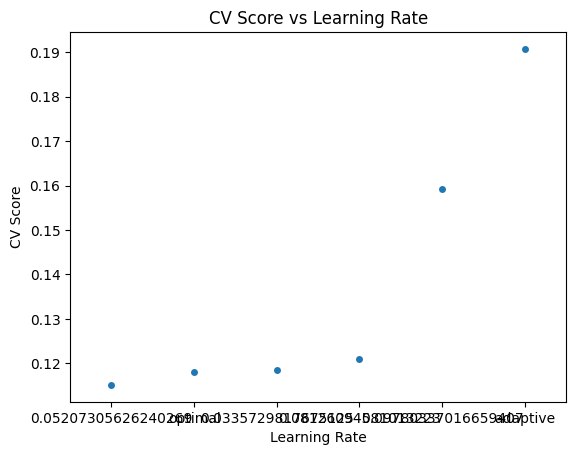

In [148]:
import matplotlib.pyplot as plt

import seaborn as sns

sns.stripplot(
    x="learning_rate",
    y="cv_score",
    data=exp_summary
)
plt.xlabel("Learning Rate")
plt.ylabel("CV Score")
plt.title("CV Score vs Learning Rate")
plt.show()

**OOF predictions (postprocessed)**

In [9]:
# Collect OOF predictions for all experiments
oof_dfs = []
for exp in experiments:
    df = pd.DataFrame(exp["oof_postprocessed_preds"], columns=[f"{exp['name']}_class0",
                                                               f"{exp['name']}_class1",
                                                               f"{exp['name']}_class2"])
    oof_dfs.append(df)

# Combine all OOF predictions
oof_combined = pd.concat(oof_dfs, axis=1)
oof_combined.head()

KeyError: 'oof_postprocessed_preds'

In [149]:
# Collect OOF predictions for all experiments
oof_dfs = []
for exp in experiments:
    df = pd.DataFrame(exp["oof_preds"], columns=[f"{exp['name']}"])
    oof_dfs.append(df)

# Combine all OOF predictions
oof_combined = pd.concat(oof_dfs, axis=1)
oof_combined.head()

,20260416-122313_elasticnet_CVScore0.1114_exp_20260416-1223_,20260416-122313_lasso_CVScore0.1099_exp_20260416-1223_,20260416-122313_random_forest_CVScore0.1336_exp_20260416-1223_max_depth20,20260416-122313_ransac_CVScore0.1906_exp_20260416-1223_,20260416-122313_ridge_CVScore0.1103_exp_20260416-1223_,20260416-122313_svm_CVScore0.1126_exp_20260416-1223_,20260416-122314_bayesian_ridge_CVScore0.1110_exp_20260416-1223_,20260416-122314_extratrees_CVScore0.1346_exp_20260416-1223_max_depth14,20260416-122314_gradient_boosting_CVScore0.1151_exp_20260416-1223_learning_rate0.05207305626240269_max_depth3,20260416-122314_lightgbm_CVScore0.1210_exp_20260416-1223_learning_rate0.08126094581013223,20260416-122314_sgd_CVScore0.1181_exp_20260416-1223_learning_rateoptimal,20260416-122314_xgboost_CVScore0.1184_exp_20260416-1223_max_depth9_learning_rate0.0335729817675125,20260416-122315_adaboost_CVScore0.1592_exp_20260416-1223_learning_rate0.09780337016659407,20260416-122315_knn_CVScore0.1569_exp_20260416-1223_,20260416-122316_kernel_ridge_CVScore0.1094_exp_20260416-1223_,20260416-122317_mlp_CVScore0.1907_exp_20260416-1223_learning_rateadaptive
0,12.213661,12.218670,12.216699,12.248742,12.214869,12.214478,12.216311,12.229406,12.206628,12.194195,12.200813,12.221978,12.205389,12.279959,12.218168,12.320282
1,12.235484,12.227709,12.078100,12.132671,12.220690,12.181083,12.220179,12.093729,12.087808,12.124220,12.195164,12.095609,11.989700,11.998485,12.185242,12.110891
2,12.248843,12.271858,12.229140,12.287016,12.266039,12.272161,12.262098,12.261734,12.283291,12.260371,12.260289,12.274142,12.247225,12.301876,12.265515,12.394961
3,12.095343,12.074325,12.167482,12.321747,12.108594,12.104656,12.125087,12.187996,12.128255,12.131706,12.168727,12.125850,12.252054,12.075806,12.131613,12.129531
4,12.558317,12.582084,12.504659,12.569223,12.592030,12.627198,12.583277,12.587115,12.607355,12.536893,12.615380,12.579950,12.451617,12.580509,12.600919,12.593969


In [150]:
y_train = np.log1p(y_train) 

In [154]:
y_train

,SalePrice
0,12.247699
1,12.109016
2,12.317171
3,11.849405
4,12.429220
...,...
1453,12.072547
1454,12.254868
1455,12.493133
1456,11.864469


In [155]:
# 1. Sort the list based on metadata['cv_score']
# reverse=False (default) sorts from lowest to highest (best for regression)
sorted_experiments = sorted(
    experiments, 
    key=lambda x: x['metadata']['cv_score']
)

# 2. Slice the top 4
selected_exps = sorted_experiments[:6]

# Print check
print(f"Total experiments found: {len(experiments)}")
print("Selected Top 6 Models:")
for i, exp in enumerate(selected_exps):
    print(f"{i+1}. {exp['metadata']['model_name']} - CV Score: {exp['metadata']['cv_score']:.6f}")

Total experiments found: 16
Selected Top 6 Models:
1. kernel_ridge - CV Score: 0.109359
2. lasso - CV Score: 0.109933
3. ridge - CV Score: 0.110289
4. bayesian_ridge - CV Score: 0.110975
5. elasticnet - CV Score: 0.111409
6. svm - CV Score: 0.112624


In [156]:
selected_exps

[{'name': '20260416-122316_kernel_ridge_CVScore0.1094_exp_20260416-1223_',
  'path': '/home/ismail/x42/outputs/experiments/20260416-122316_kernel_ridge_CVScore0.1094_exp_20260416-1223_',
  'metrics': {'RMSE': 0.0809853594229043, 'MAE': 0.05645856686181792},
  'params': {'alpha': 0.0951869049372153, 'kernel': 'poly'},
  'metadata': {'model_name': 'kernel_ridge',
   'cv_score': 0.1093592011502356,
   'best_iteration': None,
   'params': {'alpha': 0.0951869049372153, 'kernel': 'poly'},
   'train_time_seconds': 0.0,
   'num_samples': 1458,
   'num_features': 670,
   'timestamp': '2026-04-16 12:23:17'},
  'train_preds': array([12.22530697, 12.18353541, 12.27826348, ..., 12.46450089,
         11.85607073, 11.89486426]),
  'test_preds': array([11.70701495, 11.99323065, 12.13091257, ..., 12.03825753,
         11.65312842, 12.25182076]),
  'oof_preds': array([12.21816794, 12.18524238, 12.26551456, ..., 12.44454886,
         11.84169665, 11.86935531])},
 {'name': '20260416-122313_lasso_CVScore0.

In [157]:
# -----------------------------
# 1️⃣ Import packages
# -----------------------------
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from lightgbm import LGBMClassifier

# For your custom evaluation (optional)
from src.evaluation_utils import evaluate_metric


task = cfg.TASK.lower()
is_regression = task == "regression"
is_binary = task == "binary"
is_multiclass = task == "multiclass"



def build_meta_dataframe(experiments, use_oof=True):
    dfs = []
    for exp in experiments:
        name = exp["name"]
        preds = exp["oof_preds"] if use_oof else exp["test_preds"]
        
        # Determine if we have probabilities (2D) or single values (1D)
        if len(preds.shape) > 1 and preds.shape[1] > 1:
            # Multiclass or Binary with Proba
            n_classes = preds.shape[1]
            cols = [f"{name}_prob_{j}" for j in range(n_classes)]
            df = pd.DataFrame(preds, columns=cols)
        else:
            # Regression or Binary (Single value)
            df = pd.DataFrame(preds, columns=[f"{name}_pred"])
            
        dfs.append(df)
    
    meta_df = pd.concat(dfs, axis=1)
    return meta_df

X_meta_df = build_meta_dataframe(selected_exps, use_oof=True)
X_test_meta_df = build_meta_dataframe(selected_exps, use_oof=False)

In [167]:
from lightgbm import LGBMRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.metrics import mean_squared_error

def train_meta_cv(X_meta, y, X_test_meta, folds, task="regression", use_lgbm=False):
    n_samples = len(X_meta)
    n_test_samples = len(X_test_meta)
    n_splits = len(folds)
    
    # Initialize OOF and Test containers based on task
    if task == "multiclass":
        num_classes = len(np.unique(y))
        oof_meta = np.zeros((n_samples, num_classes))
        test_meta = np.zeros((n_test_samples, num_classes))
    else:
        # Regression or Binary (Single output)
        oof_meta = np.zeros(n_samples)
        test_meta = np.zeros(n_test_samples)

    for fold, (train_idx, valid_idx) in enumerate(folds):
        print(f"Meta Fold {fold+1}")
        
        X_tr, X_val = X_meta.iloc[train_idx], X_meta.iloc[valid_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[valid_idx]

        # 1. Define Meta-Model
        if task == "regression":
            model = LGBMRegressor(n_estimators=500, learning_rate=0.05, max_depth=3, random_state=42) if use_lgbm else Ridge(alpha=1.0)
        else:
            model = LGBMClassifier(n_estimators=500, learning_rate=0.05, max_depth=3, random_state=42) if use_lgbm else LogisticRegression(max_iter=1000)
        
        # 2. Fit
        model.fit(X_tr, y_tr)

        # 3. Predict OOF and Test
        if task == "multiclass":
            oof_meta[valid_idx] = model.predict_proba(X_val)
            test_meta += model.predict_proba(X_test_meta) / n_splits
        elif task == "binary":
            # Store probabilities for binary to keep more information
            oof_meta[valid_idx] = model.predict_proba(X_val)[:, 1]
            test_meta += model.predict_proba(X_test_meta)[:, 1] / n_splits
        else: # Regression
            oof_meta[valid_idx] = model.predict(X_val).ravel()
            test_meta += model.predict(X_test_meta).ravel() / n_splits

    return oof_meta, test_meta

In [168]:
# Execution
oof_meta, test_meta = train_meta_cv(
    X_meta_df,
    y_train, # Pass the original y_train Series
    X_test_meta_df,
    folds=folds,
    task=cfg.TASK.lower(),
    use_lgbm=False # Set to True for a non-linear stacker
)

# Evaluation
if is_regression:
    score = np.sqrt(mean_squared_error(y_train, oof_meta))
    print(f"STACKING RMSE (OOF): {score:.4f}")
else:
    # Get classes for Accuracy/F1
    if is_binary:
        pred_classes = (oof_meta > 0.5).astype(int)
    else:
        pred_classes = np.argmax(oof_meta, axis=1)
        
    score = accuracy_score(y_train, pred_classes)
    print(f"STACKING ACCURACY (OOF): {score:.4f}")


# -----------------------------
# 7️⃣ Make predictions for submission
# -----------------------------

# Determine the final target values based on the task
if is_regression:
    # For regression, the meta-model output is the direct prediction
    final_preds = np.expm1(test_meta)  # Inverse of log1p to get back original scale
elif is_binary:
    # For binary, test_meta contains probabilities of class 1
    # Convert to 0 or 1 based on 0.5 threshold
    final_preds = (test_meta > 0.5).astype(int)
else:
    # For multiclass, test_meta is 2D (samples x classes)
    # Take the index of the highest probability
    final_preds = np.argmax(test_meta, axis=1)

# Create the submission DataFrame
submission = pd.DataFrame({
    ID: test_ids,
    TARGET: final_preds
})

# Optional: Map numeric classes back to original labels if they were strings
# if not is_regression and hasattr(label_encoder, "inverse_transform"):
#     submission["target"] = label_encoder.inverse_transform(submission["target"])

submission.to_csv("../outputs/submissions/stacking_submission.csv", index=False)
print(f"Submission saved with {len(submission)} rows!")
display(submission.head())

Meta Fold 1
Meta Fold 2
Meta Fold 3
Meta Fold 4
Meta Fold 5
STACKING RMSE (OOF): 0.1096
Submission saved with 1459 rows!


,Id,SalePrice
0,1461,121502.147675
1,1462,159252.057904
2,1463,184625.923556
3,1464,199676.466768
4,1465,194044.710400


In [161]:
test_ids

In [31]:
y_train

,SalePrice
0,12.247699
1,12.109016
2,12.317171
3,11.849405
4,12.429220
...,...
1455,12.072547
1456,12.254868
1457,12.493133
1458,11.864469


In [170]:
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.preprocessing import StandardScaler
from src.evaluation_utils import evaluate_metric
from pathlib import Path
from joblib import Parallel, delayed
import optuna

class AdvancedStackingEngine:
    def __init__(
        self,
        base_models,
        meta_model,
        folds,
        task="regression", # Default to regression
        metric="rmse",      # Default to rmse
        use_weights=True,
        feature_engineering=False,
        n_jobs=1,
        seed=42
    ):
        self.base_models = base_models
        self.meta_model = meta_model
        self.folds = folds
        self.task = task.lower()
        self.metric = metric.lower()
        self.use_weights = use_weights
        self.feature_engineering = feature_engineering
        self.n_jobs = n_jobs
        self.seed = seed
        self.opt_weights = np.ones(len(base_models))
        
        # Determine optimization direction
        self.direction = "minimize" if any(m in self.metric for m in ["rmse", "mae", "mse", "loss"]) else "maximize"

    def build_meta_dataframe(self, use_oof=True, weights=None):
        dfs = []
        for i, exp in enumerate(self.base_models):
            name = exp["name"]
            preds = exp["oof_preds"] if use_oof else exp.get("test_preds")
            
            if preds is None:
                raise ValueError(f"{name} does not have {'OOF' if use_oof else 'test'} predictions")
            
            # Apply weights if provided
            if weights is not None:
                preds = preds * weights[i]
            
            # --- TASK-BASED COLUMN NAMING ---
            if len(preds.shape) > 1 and preds.shape[1] > 1:
                # Multiclass
                cols = [f"{name}_class_{j}" for j in range(preds.shape[1])]
            else:
                # Regression or Binary
                cols = [f"{name}_pred"]
                
            df = pd.DataFrame(preds, columns=cols)
            dfs.append(df)

        meta_df = pd.concat(dfs, axis=1)

        if self.feature_engineering:
            meta_df["mean_prob"] = meta_df.mean(axis=1)
            meta_df["std_prob"] = meta_df.std(axis=1)
            # Only for classification probs
            if self.task != "regression":
                meta_df["max_prob"] = meta_df.max(axis=1)

        return meta_df

    def _get_preds(self, model, X):
        """Helper to get right predictions based on task"""
        if self.task == "multiclass":
            return model.predict_proba(X)
        elif self.task == "binary":
            # Return probability of positive class if available, else hard class
            return model.predict_proba(X)[:, 1] if hasattr(model, "predict_proba") else model.predict(X)
        else: # regression
            return model.predict(X).ravel()

    def _fit_fold(self, X_meta, y, train_idx, val_idx):
        X_tr, X_val = X_meta.iloc[train_idx], X_meta.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = clone(self.meta_model)
        model.fit(X_tr, y_tr)
        pred_val = self._get_preds(model, X_val)
        return val_idx, pred_val, model

    def fit_meta_model(self, X_meta, y):
        # Determine shape of OOF container
        sample_pred = self.base_models[0]["oof_preds"]
        if self.task == "multiclass":
            n_cols = sample_pred.shape[1]
            oof_pred_meta = np.zeros((len(y), n_cols))
        else:
            oof_pred_meta = np.zeros(len(y))

        results = Parallel(n_jobs=self.n_jobs)(
            delayed(self._fit_fold)(X_meta, y, train_idx, val_idx)
            for train_idx, val_idx in self.folds
        )

        for val_idx, pred_val, _ in results:
            oof_pred_meta[val_idx] = pred_val

        score = evaluate_metric(y_true=y, y_input=oof_pred_meta, task=self.task, kaggle_eval=self.metric)
        print(f"STACKING OOF {self.metric.upper()}: {score:.4f}")

        self.meta_model.fit(X_meta, y)
        return oof_pred_meta

    def predict(self, X_meta):
        return self._get_preds(self.meta_model, X_meta)

    def optimize_weights(self, y_train, n_trials=50):
        def objective(trial):
            weights = [trial.suggest_float(f"w{i}", 0.0, 2.0) for i in range(len(self.base_models))]
            X_meta = self.build_meta_dataframe(use_oof=True, weights=weights)
            
            # Simple internal CV for weight speed
            sample_pred = self.base_models[0]["oof_preds"]
            oof_shape = (len(y_train), sample_pred.shape[1]) if self.task == "multiclass" else (len(y_train),)
            oof_pred_meta = np.zeros(oof_shape)

            for train_idx, val_idx in self.folds:
                X_tr, X_val = X_meta.iloc[train_idx], X_meta.iloc[val_idx]
                y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
                model = clone(self.meta_model)
                model.fit(X_tr, y_tr)
                oof_pred_meta[val_idx] = self._get_preds(model, X_val)

            return evaluate_metric(y_true=y_train, y_input=oof_pred_meta, task=self.task, kaggle_eval=self.metric)

        study = optuna.create_study(direction=self.direction)
        study.optimize(objective, n_trials=n_trials, n_jobs=self.n_jobs)
        self.opt_weights = np.array([study.best_params[f"w{i}"] for i in range(len(self.base_models))])
        print(f"Optimal weights: {self.opt_weights}")
        return self.opt_weights

    def run(self, y_train, optimize=True, n_trials=50):
        if self.use_weights and optimize:
            self.optimize_weights(y_train, n_trials=n_trials)
        
        X_meta_df = self.build_meta_dataframe(use_oof=True, weights=self.opt_weights if self.use_weights else None)
        oof_pred_meta = self.fit_meta_model(X_meta_df, y_train)
        X_test_meta_df = self.build_meta_dataframe(use_oof=False, weights=self.opt_weights if self.use_weights else None)
        test_pred_meta = self.predict(X_test_meta_df)
        return oof_pred_meta, test_pred_meta, X_meta_df, X_test_meta_df




# 2. Choose meta-model based on task
if cfg.TASK == "regression":
    meta_model = Ridge(alpha=1.0)
    metric_name = "rmse"
else:
    meta_model = LogisticRegression(max_iter=1000)
    metric_name = "accuracy"

# 3. Initialize Engine
stack_engine = AdvancedStackingEngine(
    base_models=selected_exps,
    meta_model=meta_model,
    folds=folds,
    task=cfg.TASK,
    metric=metric_name,
    use_weights=True,
    feature_engineering=False,
    n_jobs=4
)

# 4. Run (using y_train)
oof_pred_meta, test_pred_meta, X_meta_df, X_test_meta_df = stack_engine.run(
    y_train, optimize=True, n_trials=20
)

[I 2026-04-16 12:28:50,604] A new study created in memory with name: no-name-fee3b921-0ba1-475f-8b33-28877cc7eae6
[I 2026-04-16 12:28:50,739] Trial 1 finished with value: 0.10945642348754822 and parameters: {'w0': 1.7730111038516099, 'w1': 1.1044431321755852, 'w2': 1.1968618099480708, 'w3': 0.09043667835918456, 'w4': 1.6888355573923983, 'w5': 0.9857644273950545}. Best is trial 1 with value: 0.10945642348754822.
[I 2026-04-16 12:28:50,741] Trial 2 finished with value: 0.10965355946691746 and parameters: {'w0': 1.0627728381096888, 'w1': 1.0805535102974448, 'w2': 0.40447791471341765, 'w3': 1.2690105213387224, 'w4': 1.8307775019741166, 'w5': 1.2303762508585574}. Best is trial 1 with value: 0.10945642348754822.
[I 2026-04-16 12:28:50,768] Trial 3 finished with value: 0.10943685939647713 and parameters: {'w0': 1.7720731188220176, 'w1': 1.0643224622315026, 'w2': 1.4283556192917737, 'w3': 1.3160925867520619, 'w4': 1.3078294583645111, 'w5': 0.14727205634349771}. Best is trial 3 with value: 0.10

Optimal weights: [1.56430517 1.9788862  1.56142171 1.63940594 0.81776327 0.52169267]
STACKING OOF RMSE: 0.1094


In [171]:
apply_exp = (cfg.TASK == "regression") 

# Determine final target values
if cfg.TASK == "regression":
    # If you trained on log-targets, use np.expm1 to get back to dollars
    final_preds = np.expm1(test_pred_meta) if apply_exp else test_pred_meta
    
elif cfg.TASK == "binary":
    # test_pred_meta contains probabilities of class 1
    final_preds = (test_pred_meta > 0.5).astype(int)
    
else:
    # Multiclass: take index of max probability
    final_preds = np.argmax(test_pred_meta, axis=1)

# --- CREATE SUBMISSION ---
submission = pd.DataFrame({
    ID: test_ids,
    TARGET: final_preds
})



# Save to your Arch Linux directory structure
out_path = Path("../outputs/submissions/stacking_submission_v2.csv")
out_path.parent.mkdir(parents=True, exist_ok=True) # Ensure folder exists

submission.to_csv(out_path, index=False)

print(f"=== Stacking Finished ===")
print(f"Optimal weights: {stack_engine.opt_weights}")
print(f"Submission saved to: {out_path}")
display(submission.head())

=== Stacking Finished ===
Optimal weights: [1.56430517 1.9788862  1.56142171 1.63940594 0.81776327 0.52169267]
Submission saved to: ../outputs/submissions/stacking_submission_v2.csv


,Id,SalePrice
0,1461,121447.955710
1,1462,161024.678095
2,1463,184021.578060
3,1464,199247.165294
4,1465,194034.008339


In [141]:
X_train

,0,1,2,3,4,5,6,7,8,9,...,380,381,382,383,384,385,386,387,388,389
0,-0.25,-0.266140,0.5,0.0,0.663043,0.243243,1.035024,0.455696,0.000000,-0.559829,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.50,0.030467,0.0,3.0,0.076087,-0.486486,0.000000,0.838256,0.000000,-0.330769,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-0.10,0.399160,0.5,0.0,0.619565,0.216216,0.997909,0.146273,0.000000,-0.074359,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-0.50,0.018328,0.5,0.0,-1.184783,-0.648649,0.000000,-0.233474,0.000000,0.106838,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,-1.0,0.0
4,0.70,0.950309,1.0,0.0,0.597826,0.162162,1.148177,0.383966,0.000000,0.021368,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1453,-0.40,-0.417593,0.0,0.0,0.576087,0.162162,0.000000,-0.537271,0.000000,0.812821,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1454,0.75,0.766342,0.0,1.0,0.119565,-0.162162,0.937910,0.573840,5.099866,0.190598,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1455,-0.20,-0.108735,0.5,4.0,-0.641304,0.324324,0.000000,-0.150492,0.000000,0.682906,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1456,-0.10,0.058626,-0.5,1.0,-0.489130,0.054054,0.000000,-0.468354,6.937314,-0.816239,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [36]:
# import numpy as np
# import pandas as pd
# from sklearn.base import clone
# from sklearn.linear_model import Ridge, Lasso, LogisticRegressionCV
# from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
# from sklearn.preprocessing import RobustScaler
# from joblib import Parallel, delayed
# import optuna
# from pathlib import Path

# class DynamicStackingEngine:
#     """
#     Highly advanced, customizable stacking engine.
#     Supports:
#     - Dynamic Meta-Estimator selection.
#     - Automated feature scaling for the meta-layer.
#     - Residual-based weighting.
#     - Bagged inference across all folds.
#     """
#     def __init__(
#         self,
#         base_models,
#         folds,
#         meta_estimators=None, # List of (name, model) tuples
#         task="regression",
#         metric="rmse",
#         include_original_features=False,
#         n_jobs=4
#     ):
#         self.base_models = base_models
#         self.folds = folds
#         self.task = task.lower()
#         self.metric = metric.lower()
#         self.include_original_features = include_original_features
#         self.n_jobs = n_jobs
        
#         # Default dynamic meta-learners if none provided
#         if meta_estimators is None:
#             if self.task == "regression":
#                 self.meta_estimators = {
#                     "linear": Ridge(alpha=1.0),
#                     "trees": ExtraTreesRegressor(n_estimators=200, max_depth=5, n_jobs=-1)
#                 }
#             else:
#                 self.meta_estimators = {
#                     "linear": LogisticRegressionCV(max_iter=2000),
#                     "trees": RandomForestRegressor(n_estimators=200, max_depth=5, n_jobs=-1)
#                 }
#         else:
#             self.meta_estimators = meta_estimators

#         self.opt_weights = np.ones(len(base_models))
#         self.meta_models_library = {name: [] for name in self.meta_estimators.keys()}
#         self.direction = "minimize" if any(m in self.metric for m in ["rmse", "mae", "mse", "loss"]) else "maximize"

#     def _prepare_data(self, y, X_raw=None):
#         """Standardizes input shapes and applies target transformations."""
#         y_flat = np.array(y).ravel()
#         if self.task == "regression" and pd.Series(y_flat).skew() > 1.0:
#             self.target_transform = True
#             y_flat = np.log1p(y_flat)
#         else:
#             self.target_transform = False
#         return pd.Series(y_flat)

#     def build_meta_df(self, use_oof=True, weights=None, X_raw=None):
#         """Constructs meta-features, optionally injecting original raw features."""
#         dfs = []
#         for i, exp in enumerate(self.base_models):
#             preds = exp["oof_preds"] if use_oof else exp.get("test_preds")
#             if weights is not None:
#                 preds = preds * weights[i]
            
#             name = exp["name"]
#             cols = [f"{name}_c{j}" for j in range(preds.shape[1])] if preds.ndim > 1 else [f"{name}_p"]
#             dfs.append(pd.DataFrame(preds, columns=cols))
        
#         meta_df = pd.concat(dfs, axis=1)
        
#         if self.include_original_features and X_raw is not None:
#             X_raw_reset = X_raw.reset_index(drop=True)
#             meta_df = pd.concat([meta_df, X_raw_reset], axis=1)
            
#         return meta_df

#     def optimize_weights(self, y_train, n_trials=30):
#         """Optuna trial to find the best blending weights for base models."""
#         y_fit = self._prepare_data(y_train)
        
#         def objective(trial):
#             w = [trial.suggest_float(f"w{i}", 0.0, 2.0) for i in range(len(self.base_models))]
#             X_meta = self.build_meta_df(use_oof=True, weights=w)
            
#             # Use a fast internal meta-learner for weight search
#             internal_m = Ridge() if self.task == "regression" else LogisticRegressionCV()
#             oof_p = np.zeros_like(self.base_models[0]["oof_preds"])

#             for tr_idx, val_idx in self.folds:
#                 m = clone(internal_m).fit(X_meta.iloc[tr_idx], y_fit.iloc[tr_idx])
#                 oof_p[val_idx] = m.predict(X_meta.iloc[val_idx])

#             return evaluate_metric(y_true=y_fit, y_input=oof_p, task=self.task, kaggle_eval=self.metric)

#         study = optuna.create_study(direction=self.direction)
#         study.optimize(objective, n_trials=n_trials, n_jobs=self.n_jobs)
#         self.opt_weights = np.array([study.best_params[f"w{i}"] for i in range(len(self.base_models))])

#     def fit(self, X_raw, y_train, optimize=True, n_trials=30):
#         """Trains all meta-estimators using Bagged Cross-Validation."""
#         if optimize:
#             self.optimize_weights(y_train, n_trials)
            
#         y_fit = self._prepare_data(y_train)
#         X_meta = self.build_meta_df(use_oof=True, weights=self.opt_weights, X_raw=X_raw)
        
#         # Scale meta-features (critical for Linear/NN meta-models)
#         self.scaler = RobustScaler().fit(X_meta)
#         X_meta_scaled = pd.DataFrame(self.scaler.transform(X_meta), columns=X_meta.columns)

#         def _fit_fold(tr_idx, val_idx):
#             xt, xv = X_meta_scaled.iloc[tr_idx], X_meta_scaled.iloc[val_idx]
#             yt = y_fit.iloc[tr_idx]
            
#             fold_results = {}
#             for name, estimator in self.meta_estimators.items():
#                 m = clone(estimator).fit(xt, yt)
#                 fold_results[name] = (val_idx, m.predict(xv), m)
#             return fold_results

#         results = Parallel(n_jobs=self.n_jobs)(delayed(_fit_fold)(t, v) for t, v in self.folds)

#         # Reconstruct OOF and store models
#         self.oof_preds_dict = {name: np.zeros_like(y_fit, dtype=float) for name in self.meta_estimators}
#         for fold_res in results:
#             for name, (idx, preds, model) in fold_res.items():
#                 self.oof_preds_dict[name][idx] = preds
#                 self.meta_models_library[name].append(model)

#         print("--- Meta-Model OOF Scores ---")
#         for name, oof in self.oof_preds_dict.items():
#             score = evaluate_metric(y_true=y_fit, y_input=oof, task=self.task, kaggle_eval=self.metric)
#             print(f"{name.upper()}: {score:.4f}")

#     def predict(self, X_raw_test):
#         """Inference with multi-model bagging."""
#         X_test_meta = self.build_meta_df(use_oof=False, weights=self.opt_weights, X_raw=X_raw_test)
#         X_test_scaled = self.scaler.transform(X_test_meta)
        
#         final_meta_preds = []
#         for name in self.meta_estimators.keys():
#             # Average predictions from all fold-models of this type
#             type_preds = np.mean([m.predict(X_test_scaled) for m in self.meta_models_library[name]], axis=0)
#             final_meta_preds.append(type_preds)
            
#         # Blend different meta-estimator types (Simple average, or could be another Optuna)
#         blended_preds = np.mean(final_meta_preds, axis=0)
        
#         if self.target_transform:
#             return np.expm1(blended_preds)
#         return blended_preds

# # --- EXAMPLE CUSTOMIZATION ---
# custom_meta = {
#     "lasso": Lasso(alpha=0.01),
#     "ridge": Ridge(alpha=0.5),
#     "extratrees": ExtraTreesRegressor(n_estimators=500, max_depth=None, min_samples_split=10)
# }

# engine = DynamicStackingEngine(
#     base_models=selected_exps,
#     folds=folds,
#     meta_estimators=custom_meta, # <--- PASS YOUR CUSTOM MODELS HERE
#     include_original_features=False, # <--- DYNAMICALLY INJECT RAW DATA
#     task=cfg.TASK
# )

# engine.fit(X_train, y_train) # Pass X_train if include_original_features=True
# final_test_preds = engine.predict(X_test)

In [172]:
def build_meta_features(base_models,use_oof=True, weights=None):
    """Constructs the meta-feature matrix with optional weighting."""
    dfs = []
    for i, exp in enumerate(base_models):
        name = exp["name"]
        preds = exp["oof_preds"] if use_oof else exp.get("test_preds")
        
        if weights is not None:
            preds = preds * weights[i]
        
        # Handle multi-column (multiclass) vs single-column
        cols = [f"{name}_c{j}" for j in range(preds.shape[1])] if preds.ndim > 1 else [f"{name}_p"]
        dfs.append(pd.DataFrame(preds, columns=cols))
        
    return pd.concat(dfs, axis=1)

X_meta_df = build_meta_features(experiments, use_oof=True)

In [173]:
def drop_correlated_by_quality(df, experiments, threshold=0.98, verbose=True):
    """
    Drops highly correlated features, always keeping the one with the 
    BETTER (lower) CV Score.
    """
    # 1. Create a lookup for CV scores: { "exp_name_p": 0.1321 }
    # We use the suffix _p because that's how build_meta_features names them
    score_lookup = {f"{exp['name']}_p": exp['metadata']['cv_score'] for exp in experiments}
    
    corr_matrix = df.corr().abs()
    iters = range(len(corr_matrix.columns) - 1)
    drop_cols = set()

    # 2. Compare pairs and check quality
    for i in iters:
        for j in range(i + 1, len(corr_matrix.columns)):
            item_i = corr_matrix.columns[i]
            item_j = corr_matrix.columns[j]
            
            # If they are highly correlated
            if corr_matrix.iloc[i, j] >= threshold:
                if item_i not in drop_cols and item_j not in drop_cols:
                    # Get scores (default to high value if not found)
                    score_i = score_lookup.get(item_i, 999)
                    score_j = score_lookup.get(item_j, 999)
                    
                    # DROP the one with the HIGHER (worse) CV Score
                    if score_i > score_j:
                        drop_cols.add(item_i)
                    else:
                        drop_cols.add(item_j)

    if verbose:
        print(f"Detected {len(drop_cols)} redundant features based on {threshold} correlation.")
        print(f"Dropped based on inferior CV Score: {list(drop_cols)}")

    return df.drop(columns=drop_cols), list(drop_cols)

# --- APPLICATION ---
X_meta_clean, dropped_cols = drop_correlated_by_quality(X_meta_df, experiments, threshold=0.98)

Detected 10 redundant features based on 0.98 correlation.
Dropped based on inferior CV Score: ['20260416-122314_lightgbm_CVScore0.1210_exp_20260416-1223_learning_rate0.08126094581013223_p', '20260416-122314_bayesian_ridge_CVScore0.1110_exp_20260416-1223__p', '20260416-122314_gradient_boosting_CVScore0.1151_exp_20260416-1223_learning_rate0.05207305626240269_max_depth3_p', '20260416-122314_xgboost_CVScore0.1184_exp_20260416-1223_max_depth9_learning_rate0.0335729817675125_p', '20260416-122313_elasticnet_CVScore0.1114_exp_20260416-1223__p', '20260416-122313_ridge_CVScore0.1103_exp_20260416-1223__p', '20260416-122314_extratrees_CVScore0.1346_exp_20260416-1223_max_depth14_p', '20260416-122313_lasso_CVScore0.1099_exp_20260416-1223__p', '20260416-122314_sgd_CVScore0.1181_exp_20260416-1223_learning_rateoptimal_p', '20260416-122313_svm_CVScore0.1126_exp_20260416-1223__p']


In [174]:
dropped_exp_names = {col.rsplit('_', 1)[0] for col in dropped_cols}

# 2. Filter the original experiments list
selected_experiments = [
    exp for exp in experiments 
    if exp['name'] not in dropped_exp_names
]

print(f"Original experiments: {len(experiments)}")
print(f"Dropped due to correlation: {len(dropped_exp_names)}")
print(f"Final experiments for stacking: {len(selected_experiments)}")


Original experiments: 16
Dropped due to correlation: 10
Final experiments for stacking: 6


In [175]:
selected_experiments

[{'name': '20260416-122313_random_forest_CVScore0.1336_exp_20260416-1223_max_depth20',
  'path': '/home/ismail/x42/outputs/experiments/20260416-122313_random_forest_CVScore0.1336_exp_20260416-1223_max_depth20',
  'metrics': {'RMSE': 0.0633040820192323, 'MAE': 0.04045502015310703},
  'params': {'n_estimators': 300,
   'max_depth': 20,
   'max_features': None,
   'min_samples_split': 5,
   'min_samples_leaf': 3,
   'bootstrap': True},
  'metadata': {'model_name': 'random_forest',
   'cv_score': 0.13358686128177405,
   'best_iteration': None,
   'params': {'n_estimators': 300,
    'max_depth': 20,
    'max_features': None,
    'min_samples_split': 5,
    'min_samples_leaf': 3,
    'bootstrap': True},
   'train_time_seconds': 0.0,
   'num_samples': 1458,
   'num_features': 670,
   'timestamp': '2026-04-16 12:23:14'},
  'train_preds': array([12.2420718 , 12.09776759, 12.30225312, ..., 12.4450013 ,
         11.84414923, 11.91204113]),
  'test_preds': array([11.82936698, 11.95531478, 12.09883

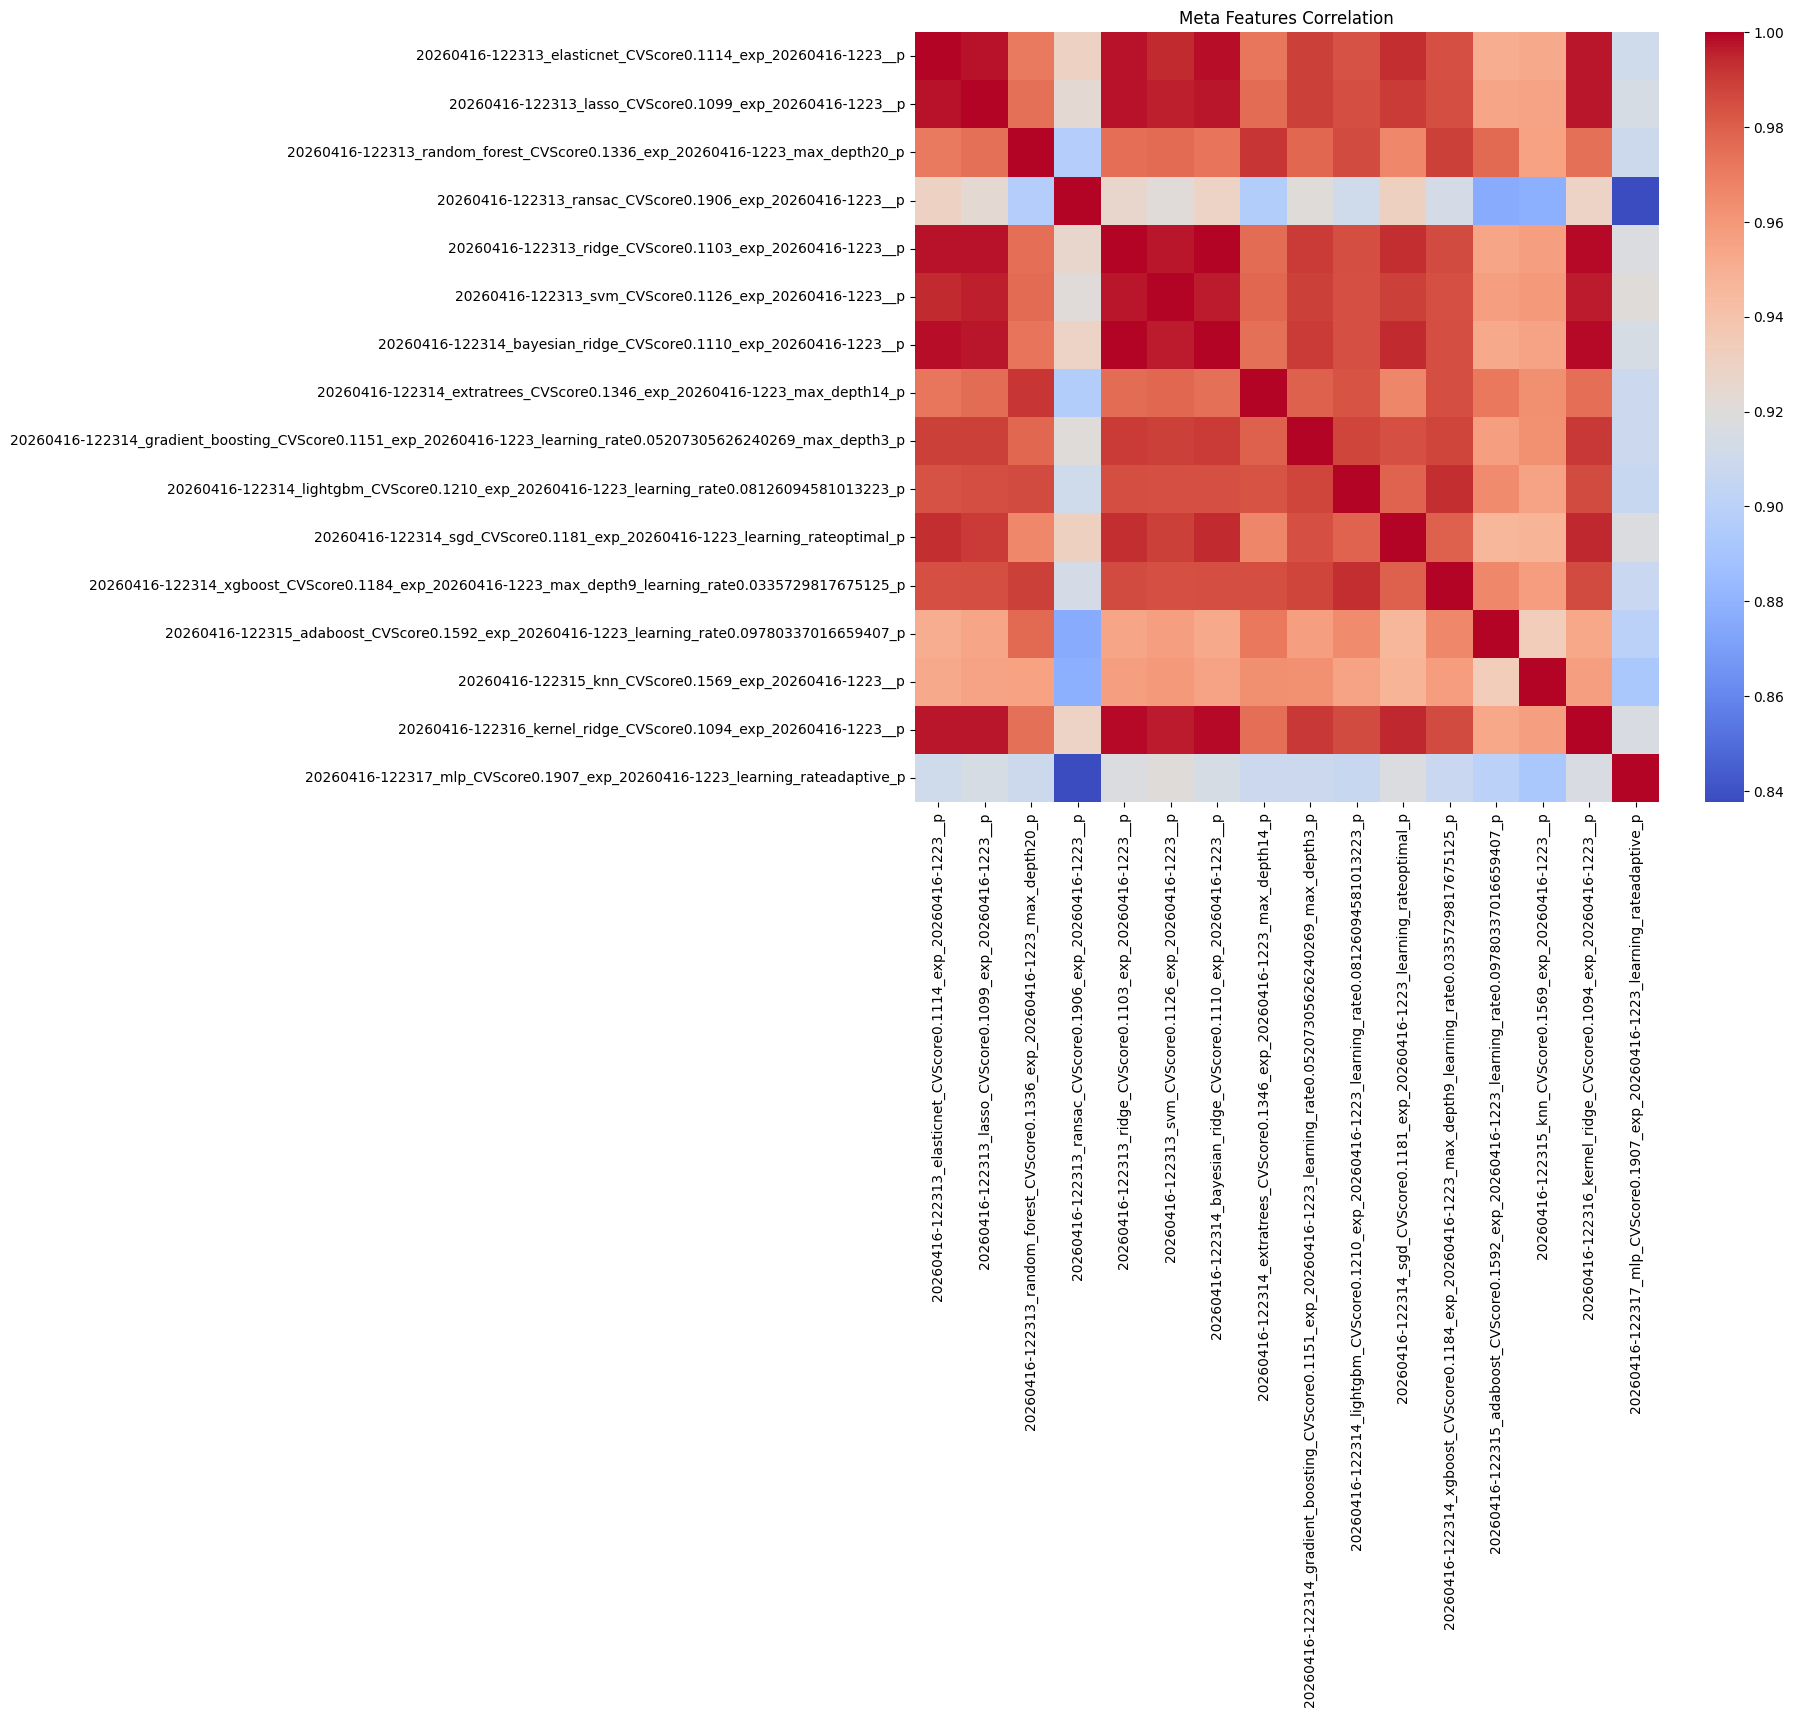

In [176]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = X_meta_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Meta Features Correlation")
plt.show()

In [177]:
selected_experiments.pop(6)
selected_experiments

IndexError: pop index out of range

In [178]:
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.linear_model import Ridge, LogisticRegressionCV
from sklearn.ensemble import ExtraTreesRegressor, ExtraTreesClassifier
from joblib import Parallel, delayed
import optuna
from pathlib import Path

class GrandmasterStackingEngine:
    """
    Advanced Stacking Engine featuring:
    - Optuna-optimized weight blending for base models.
    - Multi-Meta-Model Blending (Linear + Non-Linear trees).
    - Nested Cross-Validation for the meta-layer (Bagged Stacking).
    - Automatic Target Scaling (Skewness-aware).
    """
    def __init__(
        self,
        base_models,
        folds,
        task="regression",
        metric="rmse",
        blend_beta=0.75,     # Weight given to Linear vs Tree meta-model
        n_jobs=4,
        seed=42
    ):
        self.base_models = base_models
        self.folds = folds
        self.task = task.lower()
        self.metric = metric.lower()
        self.blend_beta = blend_beta
        self.n_jobs = n_jobs
        self.seed = seed
        
        self.opt_weights = np.ones(len(base_models))
        self.target_transform = False
        self.direction = "minimize" if any(m in self.metric for m in ["rmse", "mae", "mse", "loss"]) else "maximize"
        
        # We store meta-models for every fold to use in a "Bagged" prediction
        self.meta_models_linear = []
        self.meta_models_trees = []

    def _prepare_y(self, y):
        """Standardizes y to 1D and handles log-transform for skewed regression targets."""
        y_flat = np.array(y).ravel()
        y_s = pd.Series(y_flat)
        if self.task == "regression" and y_s.skew() > 1.0:
            print(f"Target Skew ({y_s.skew():.2f}) detected. Applying log1p.")
            self.target_transform = True
            return np.log1p(y_s)
        return y_s

    def build_meta_features(self, use_oof=True, weights=None):
            """Constructs the meta-feature matrix with strict column naming."""
            dfs = []
            for i, exp in enumerate(self.base_models):
                name = exp["name"]
                preds = exp["oof_preds"] if use_oof else exp.get("test_preds")
                
                if weights is not None:
                    preds = preds * weights[i]
                
                # --- FORCE CONSISTENT NAMING ---
                # If it's a 2D array with multiple columns (Multiclass)
                if preds.ndim > 1 and preds.shape[1] > 1:
                    cols = [f"{name}_c{j}" for j in range(preds.shape[1])]
                else:
                    # Force 1D/Single-column to always end in '_p'
                    cols = [f"{name}_p"]
                    preds = preds.reshape(-1, 1) # Ensure it's 2D for DataFrame consistency
                    
                dfs.append(pd.DataFrame(preds, columns=cols))
                
            return pd.concat(dfs, axis=1)

    def _get_preds(self, model, X):
        """Task-aware prediction helper."""
        if self.task == "multiclass":
            return model.predict_proba(X)
        elif self.task == "binary":
            return model.predict_proba(X)[:, 1] if hasattr(model, "predict_proba") else model.predict(X)
        return model.predict(X).ravel()

    def optimize_weights(self, y_train, n_trials=30):
        """Finds optimal weights for base models using Optuna."""
        y_fit = self._prepare_y(y_train)
        
        def objective(trial):
            w = [trial.suggest_float(f"w{i}", 0.0, 2.0) for i in range(len(self.base_models))]
            X_meta = self.build_meta_features(use_oof=True, weights=w)
            
            # Fast Linear Stacker for weight optimization
            model = Ridge(alpha=1.0) if self.task == "regression" else LogisticRegressionCV(max_iter=1000)
            oof_p = np.zeros_like(self.base_models[0]["oof_preds"])

            for tr_idx, val_idx in self.folds:
                m = clone(model).fit(X_meta.iloc[tr_idx], y_fit.iloc[tr_idx])
                oof_p[val_idx] = self._get_preds(m, X_meta.iloc[val_idx])

            return evaluate_metric(y_true=y_fit, y_input=oof_p, task=self.task, kaggle_eval=self.metric)

        study = optuna.create_study(direction=self.direction)
        study.optimize(objective, n_trials=n_trials, n_jobs=self.n_jobs)
        self.opt_weights = np.array([study.best_params[f"w{i}"] for i in range(len(self.base_models))])
        print(f"Optimal Weights: {self.opt_weights}")

    def fit_run(self, y_train, optimize=True, n_trials=30):
        """Executes the Nested-CV Stacking process."""
        if optimize:
            self.optimize_weights(y_train, n_trials)
            
        y_fit = self._prepare_y(y_train)
        X_meta = self.build_meta_features(use_oof=True, weights=self.opt_weights)
        
        # Meta-Model definitions
        if self.task == "regression":
            m_lin = Ridge(alpha=0.5)
            m_tree = ExtraTreesRegressor(n_estimators=300, max_depth=5, min_samples_leaf=5, n_jobs=-1)
        else:
            m_lin = LogisticRegressionCV(max_iter=2000)
            m_tree = ExtraTreesClassifier(n_estimators=300, max_depth=5, min_samples_leaf=5, n_jobs=-1)

        oof_lin = np.zeros_like(self.base_models[0]["oof_preds"])
        oof_tree = np.zeros_like(self.base_models[0]["oof_preds"])

        def _process_fold(tr_idx, val_idx):
            xt, xv = X_meta.iloc[tr_idx], X_meta.iloc[val_idx]
            yt = y_fit.iloc[tr_idx]
            
            reg_l = clone(m_lin).fit(xt, yt)
            reg_t = clone(m_tree).fit(xt, yt)
            
            return val_idx, self._get_preds(reg_l, xv), self._get_preds(reg_t, xv), reg_l, reg_t

        results = Parallel(n_jobs=self.n_jobs)(delayed(_process_fold)(t, v) for t, v in self.folds)

        for v_idx, p_l, p_t, mod_l, mod_t in results:
            oof_lin[v_idx], oof_tree[v_idx] = p_l, p_t
            self.meta_models_linear.append(mod_l)
            self.meta_models_trees.append(mod_t)

        final_oof = (self.blend_beta * oof_lin) + ((1 - self.blend_beta) * oof_tree)
        score = evaluate_metric(y_true=y_fit, y_input=final_oof, task=self.task, kaggle_eval=self.metric)
        print(f"Grandmaster Stacking OOF Score: {score:.4f}")
        return final_oof

    def predict(self, use_test=True):
        """Predicts by averaging (Bagging) all fold-fitted meta-models."""
        X = self.build_meta_features(use_oof=not use_test, weights=self.opt_weights)
        
        # Predict with all meta-models from CV
        p_lin = np.mean([self._get_preds(m, X) for m in self.meta_models_linear], axis=0)
        p_tree = np.mean([self._get_preds(m, X) for m in self.meta_models_trees], axis=0)
        
        final_preds = (self.blend_beta * p_lin) + ((1 - self.blend_beta) * p_tree)
        return np.expm1(final_preds) if self.target_transform else final_preds

# --- EXECUTION ---
engine = GrandmasterStackingEngine(
    base_models=selected_experiments,
    folds=folds,
    task=cfg.TASK,
    blend_beta=0.7 # Ridge is usually safer for meta-modeling
)

oof_p = engine.fit_run(y_train, optimize=True, n_trials=25)
test_p = engine.predict(use_test=True)

# Final formatting based on task
if cfg.TASK == "binary":
    final_preds = (test_p > 0.5).astype(int)
elif cfg.TASK == "multiclass":
    final_preds = np.argmax(test_p, axis=1)
else:
    final_preds = np.expm1(test_p)

# Create submission
submission = pd.DataFrame({ID: test_ids, TARGET: final_preds})
out_path = Path("../outputs/submissions/grandmaster_stacking_v1.csv")
out_path.parent.mkdir(parents=True, exist_ok=True)
submission.to_csv(out_path, index=False)
print(f"Submission saved to {out_path}")

[I 2026-04-16 12:29:12,432] A new study created in memory with name: no-name-01a49094-855c-40a5-a36e-2d0a147c617e
[I 2026-04-16 12:29:12,541] Trial 1 finished with value: 0.11030970439115952 and parameters: {'w0': 1.1299312847022622, 'w1': 1.8297895000689113, 'w2': 1.2431933366787826, 'w3': 0.20620934599638008, 'w4': 0.8726432908030868, 'w5': 0.9682417895185857}. Best is trial 1 with value: 0.11030970439115952.
[I 2026-04-16 12:29:12,550] Trial 0 finished with value: 0.11003819762839784 and parameters: {'w0': 0.63608467806448, 'w1': 1.1986829407903952, 'w2': 0.05151236781029045, 'w3': 0.5954971063635981, 'w4': 1.136720200443187, 'w5': 1.801646178707565}. Best is trial 0 with value: 0.11003819762839784.
[I 2026-04-16 12:29:12,572] Trial 3 finished with value: 0.10970613359204906 and parameters: {'w0': 1.050599069012533, 'w1': 1.3663503044587872, 'w2': 0.24072270554840203, 'w3': 0.05493124362692514, 'w4': 1.4560749886791977, 'w5': 0.45897882030881165}. Best is trial 3 with value: 0.10970

Optimal Weights: [1.53660899e+00 5.80889897e-01 4.69268455e-01 9.65320635e-04
 1.97477170e+00 6.58536129e-01]
Grandmaster Stacking OOF Score: 0.1101
Submission saved to ../outputs/submissions/grandmaster_stacking_v1.csv


### **Averaging**

In [179]:
import numpy as np
import pandas as pd
from joblib import Parallel, delayed
import optuna
from pathlib import Path

class GrandmasterAveragingEngine:
    """
    Advanced Averaging Engine featuring:
    - Shape-robust blending for Regression, Binary, and Multiclass.
    - Optuna-optimized weights (minimizes specific metric).
    - Power Averaging (p-norm blending for regression).
    - Rank Averaging (order-based blending for classification).
    - Quality-aware correlation filtering.
    """
    def __init__(
        self,
        base_models,
        task="regression",
        metric="rmse",
        method="weighted", 
        power=2,           
        n_jobs=4
    ):
        self.task = task.lower()
        self.metric = metric.lower()
        self.method = method.lower()
        self.power = power
        self.n_jobs = n_jobs
        
        # Filter models by correlation, keeping the best CV scorers
        self.base_models = self._filter_redundant_models(base_models)
        self.opt_weights = None
        self.direction = "minimize" if any(m in self.metric for m in ["rmse", "mae", "mse", "loss"]) else "maximize"

    def _normalize_shape(self, p):
        """Standardizes array dimensions based on task."""
        p = np.array(p)
        # Flatten only for regression/binary if they come in (N, 1)
        if (self.task in ["regression", "binary"]) and p.ndim > 1:
            return p.ravel()
        return p

    def _filter_redundant_models(self, models, threshold=0.98):
        """Removes highly correlated models while preserving better CV scores."""
        # Use first column for correlation check (works for all tasks)
        temp_df = pd.concat([
            pd.Series(self._normalize_shape(m["oof_preds"]).reshape(len(m["oof_preds"]), -1)[:, 0]) 
            for m in models
        ], axis=1)
        
        corr_matrix = temp_df.corr().abs()
        to_drop = set()
        
        for i in range(len(models)):
            for j in range(i + 1, len(models)):
                if corr_matrix.iloc[i, j] >= threshold:
                    score_i = models[i]['metadata'].get('cv_score', 999)
                    score_j = models[j]['metadata'].get('cv_score', 999)
                    if score_i > score_j:
                        to_drop.add(i)
                    else:
                        to_drop.add(j)
        
        final_list = [m for idx, m in enumerate(models) if idx not in to_drop]
        print(f"Filter: Kept {len(final_list)}/{len(models)} models (Threshold: {threshold})")
        return final_list

    def optimize_weights(self, y_true, n_trials=50):
        """Finds optimal blend weights using Optuna."""
        y_true = np.array(y_true)
        oofs = [self._normalize_shape(m["oof_preds"]) for m in self.base_models]

        def objective(trial):
            w = np.array([trial.suggest_float(f"w{i}", 0.0, 1.0) for i in range(len(oofs))])
            w = w / np.sum(w)
            
            # Use loop to accumulate to avoid inhomogeneous array issues
            blend = np.zeros_like(oofs[0], dtype=float)
            for i in range(len(oofs)):
                blend += w[i] * oofs[i]
                
            return evaluate_metric(y_true, blend, self.task, self.metric)

        study = optuna.create_study(direction=self.direction)
        study.optimize(objective, n_trials=n_trials, n_jobs=self.n_jobs)
        
        raw_weights = np.array([study.best_params[f"w{i}"] for i in range(len(oofs))])
        self.opt_weights = raw_weights / np.sum(raw_weights)
        print(f"Optimal Weights: {self.opt_weights}")

    def blend(self, use_test=True, method=None):
            """Performs robust blending. Method override allowed for comparison."""
            current_method = method.lower() if method else self.method
            
            preds_list = [
                self._normalize_shape(m["test_preds"] if use_test else m["oof_preds"]) 
                for m in self.base_models
            ]
            
            # 1. Simple Average (Unweighted)
            if current_method == "simple":
                return np.mean(preds_list, axis=0)

            # 2. Power Average
            elif current_method == "power":
                stacked = np.stack(preds_list)
                return np.power(np.mean(np.power(stacked, self.power), axis=0), 1/self.power)
            
            # 3. Rank Average
            elif current_method == "rank":
                if preds_list[0].ndim > 1:
                    combined = np.zeros_like(preds_list[0])
                    for c in range(preds_list[0].shape[1]):
                        combined[:, c] = np.mean([pd.Series(p[:, c]).rank(pct=True).values for p in preds_list], axis=0)
                    return combined
                else:
                    return np.mean([pd.Series(p).rank(pct=True).values for p in preds_list], axis=0)
                
            # 4. Weighted Arithmetic Mean (Optuna)
            else: 
                weights = self.opt_weights if self.opt_weights is not None else np.ones(len(preds_list)) / len(preds_list)
                combined = np.zeros_like(preds_list[0], dtype=float)
                for i in range(len(preds_list)):
                    combined += weights[i] * preds_list[i]
                return combined

# --- EXECUTION ---
avg_engine = GrandmasterAveragingEngine(
    base_models=selected_experiments, 
    task=cfg.TASK, 
    method="weighted"  # power/rank/weighted
)

# A. Simple Average (No training required)
simple_oof_preds = avg_engine.blend(use_test=False, method="simple")
simple_oof_score = evaluate_metric(y_train, simple_oof_preds, cfg.TASK, cfg.METRIC)

# B. Optimized Weighted Average
avg_engine.optimize_weights(y_train, n_trials=100)
weighted_oof_preds = avg_engine.blend(use_test=False, method="weighted")
weighted_oof_score = evaluate_metric(y_train, weighted_oof_preds, cfg.TASK, cfg.METRIC)

print(f"\n" + "="*40)
print(f"Simple Average OOF {cfg.METRIC.upper()}:   {simple_oof_score:.5f}")
print(f"Weighted Average OOF {cfg.METRIC.upper()}: {weighted_oof_score:.5f}")
print(f"Improvement: {simple_oof_score - weighted_oof_score:.5f}" if avg_engine.direction == "minimize" else f"Improvement: {weighted_oof_score - simple_oof_score:.5f}")
print("="*40 + "\n")

final_test_preds = avg_engine.blend(use_test=True, method="weighted")
print("method chosen:", avg_engine.method)

# Format based on task
if cfg.TASK == "multiclass":
    final_outputs = np.argmax(final_test_preds, axis=1)
elif cfg.TASK == "binary":
    final_outputs = (final_test_preds > 0.5).astype(int)
else:
    final_outputs = np.expm1(final_test_preds)

submission = pd.DataFrame({ID: test_ids, TARGET: final_outputs})
submission.to_csv("../outputs/submissions/grandmaster_averaging_v1.csv", index=False)
print("Submission saved: grandmaster_averaging_v1.csv")

[I 2026-04-16 12:29:44,629] A new study created in memory with name: no-name-0868cedf-8ed4-4624-8b80-be97fb058b95
[I 2026-04-16 12:29:44,638] Trial 3 finished with value: 0.12115086474783658 and parameters: {'w0': 0.9778834193589883, 'w1': 0.11913123409130266, 'w2': 0.4544700309045402, 'w3': 0.48103804914307813, 'w4': 0.6727412365744138, 'w5': 0.009390210686439415}. Best is trial 3 with value: 0.12115086474783658.
[I 2026-04-16 12:29:44,639] Trial 2 finished with value: 0.12319770553527788 and parameters: {'w0': 0.9436948361461938, 'w1': 0.3695595932625485, 'w2': 0.8294146548330169, 'w3': 0.7062367862077444, 'w4': 0.7696899139543141, 'w5': 0.486813377155089}. Best is trial 3 with value: 0.12115086474783658.
[I 2026-04-16 12:29:44,640] Trial 1 finished with value: 0.13380287544117178 and parameters: {'w0': 0.18702030313573226, 'w1': 0.8063486271571251, 'w2': 0.2929823723782816, 'w3': 0.23072595627523362, 'w4': 0.13840699654666322, 'w5': 0.7475932738617211}. Best is trial 3 with value: 0

[I 2026-04-16 12:29:44,751] Trial 14 finished with value: 0.12089297124890706 and parameters: {'w0': 0.990157419309454, 'w1': 0.9707217577516817, 'w2': 0.6366022734275321, 'w3': 0.008159141195300701, 'w4': 0.9976971619207589, 'w5': 0.050216773877271415}. Best is trial 14 with value: 0.12089297124890706.
[I 2026-04-16 12:29:44,752] Trial 12 finished with value: 0.12135268749758188 and parameters: {'w0': 0.9999158026631328, 'w1': 0.9993132221098024, 'w2': 0.6178630720197185, 'w3': 0.00210881905352886, 'w4': 0.9629931081105407, 'w5': 0.03924249075347375}. Best is trial 14 with value: 0.12089297124890706.
[I 2026-04-16 12:29:44,753] Trial 11 finished with value: 0.121369848533489 and parameters: {'w0': 0.9747477184392357, 'w1': 0.9842041250128164, 'w2': 0.6012729574571067, 'w3': 0.018985542949835177, 'w4': 0.9272002995604108, 'w5': 0.0730083262038136}. Best is trial 14 with value: 0.12089297124890706.
[I 2026-04-16 12:29:44,756] Trial 13 finished with value: 0.12112626533865287 and paramet

Filter: Kept 6/6 models (Threshold: 0.98)


[I 2026-04-16 12:29:44,833] Trial 18 finished with value: 0.12384602806807969 and parameters: {'w0': 0.7671881345841343, 'w1': 0.7164274818440394, 'w2': 0.7359638744027341, 'w3': 0.21557491868761985, 'w4': 0.41350881514178806, 'w5': 0.15776695804190025}. Best is trial 14 with value: 0.12089297124890706.
[I 2026-04-16 12:29:44,834] Trial 16 finished with value: 0.12741767654878364 and parameters: {'w0': 0.7763669108936795, 'w1': 0.7123149226308366, 'w2': 0.7357220472230982, 'w3': 0.2142369982792977, 'w4': 0.41969616699876555, 'w5': 0.9399317471374546}. Best is trial 14 with value: 0.12089297124890706.
[I 2026-04-16 12:29:44,836] Trial 17 finished with value: 0.12785747679559065 and parameters: {'w0': 0.7353784196540795, 'w1': 0.7284889418892133, 'w2': 0.7880838068904518, 'w3': 0.2178642749649387, 'w4': 0.38064436067957647, 'w5': 0.9288113487242046}. Best is trial 14 with value: 0.12089297124890706.
[I 2026-04-16 12:29:44,845] Trial 15 finished with value: 0.12865222525754574 and paramet

Optimal Weights: [0.10853826 0.19613434 0.08098457 0.09630279 0.51085849 0.00718154]

Simple Average OOF RMSE:   0.12358
Weighted Average OOF RMSE: 0.11476
Improvement: 0.00883

method chosen: weighted
Submission saved: grandmaster_averaging_v1.csv


In [ ]:
import numpy as np
import pandas as pd
from joblib import Parallel, delayed
import optuna
from pathlib import Path

class GrandmasterAveragingEngine:
    def __init__(
        self,
        base_models,
        task="regression",
        metric="rmse",
        method="weighted", 
        power=2,           
        n_jobs=4,
        weight_bounds=(0.0, 1.0),
        top_k_models=None,
        drop_corr_models=True,
        corr_threshold=0.98,
        seed=42
    ):
        self.task = task.lower()
        self.metric = metric.lower()
        self.method = method.lower()
        self.power = power
        self.n_jobs = n_jobs
        self.weight_bounds = weight_bounds
        self.seed = seed
        self.direction = "minimize" if any(m in self.metric for m in ["rmse", "mae", "mse", "loss"]) else "maximize"
        
        # 1. Automatic Correlation Filter
        if drop_corr_models:
            filtered_models = self._filter_redundant_models(base_models, threshold=corr_threshold)
        else:
            print("Control: drop_corr_models=False. Skipping redundancy filter.")
            filtered_models = base_models
        
        # 2. Top-K Selection
        if top_k_models is not None:
            reverse_sort = (self.direction == "maximize")
            filtered_models = sorted(
                filtered_models, 
                key=lambda x: x['metadata'].get('cv_score', 999), 
                reverse=reverse_sort
            )[:top_k_models]

        self.base_models = filtered_models
        self.opt_weights = None

    def _normalize_shape(self, p):
        p = np.array(p)
        if (self.task in ["regression", "binary"]) and p.ndim > 1:
            return p.ravel()
        return p

    def _filter_redundant_models(self, models, threshold=0.98):
        temp_df = pd.concat([
            pd.Series(self._normalize_shape(m["oof_preds"]).reshape(len(m["oof_preds"]), -1)[:, 0]) 
            for m in models
        ], axis=1)
        
        corr_matrix = temp_df.corr().abs()
        to_drop = set()
        for i in range(len(models)):
            for j in range(i + 1, len(models)):
                if corr_matrix.iloc[i, j] >= threshold:
                    score_i = models[i]['metadata'].get('cv_score', 999)
                    score_j = models[j]['metadata'].get('cv_score', 999)
                    if self.direction == "minimize":
                        if score_i > score_j: to_drop.add(i)
                        else: to_drop.add(j)
                    else:
                        if score_i < score_j: to_drop.add(i)
                        else: to_drop.add(j)
        
        final_list = [m for idx, m in enumerate(models) if idx not in to_drop]
        return final_list

    def optimize_weights(self, y_true, n_trials=100, timeout=None):
        y_true = np.array(y_true)
        oofs = [self._normalize_shape(m["oof_preds"]) for m in self.base_models]

        def objective(trial):
            w = np.array([
                trial.suggest_float(f"w{i}", self.weight_bounds[0], self.weight_bounds[1]) 
                for i in range(len(oofs))
            ])
            if np.sum(w) == 0: return 1e9 if self.direction == "minimize" else -1e9
            w = w / np.sum(w)
            blend = np.zeros_like(oofs[0], dtype=float)
            for i in range(len(oofs)):
                blend += w[i] * oofs[i]
            return evaluate_metric(y_true, blend, self.task, self.metric)

        sampler = optuna.samplers.TPESampler(seed=self.seed)
        study = optuna.create_study(direction=self.direction, sampler=sampler)
        study.optimize(objective, n_trials=n_trials, n_jobs=self.n_jobs, timeout=timeout)
        
        raw_weights = np.array([study.best_params[f"w{i}"] for i in range(len(oofs))])
        self.opt_weights = raw_weights / np.sum(raw_weights)

    def blend(self, use_test=True, method=None):
        current_method = method.lower() if method else self.method
        preds_list = [
            self._normalize_shape(m["test_preds"] if use_test else m["oof_preds"]) 
            for m in self.base_models
        ]
        
        if current_method == "simple":
            return np.mean(preds_list, axis=0)
        elif current_method == "power":
            stacked = np.stack(preds_list)
            return np.power(np.mean(np.power(stacked, self.power), axis=0), 1/self.power)
        elif current_method == "rank":
            if preds_list[0].ndim > 1:
                combined = np.zeros_like(preds_list[0])
                for c in range(preds_list[0].shape[1]):
                    combined[:, c] = np.mean([pd.Series(p[:, c]).rank(pct=True).values for p in preds_list], axis=0)
                return combined
            return np.mean([pd.Series(p).rank(pct=True).values for p in preds_list], axis=0)
        else:
            weights = self.opt_weights if self.opt_weights is not None else np.ones(len(preds_list)) / len(preds_list)
            combined = np.zeros_like(preds_list[0], dtype=float)
            for i in range(len(preds_list)):
                combined += weights[i] * preds_list[i]
            return combined

# --- EXECUTION ---
avg_engine = GrandmasterAveragingEngine(
    base_models=experiments, 
    task=cfg.TASK, 
    method="weighted",
    weight_bounds=(0.0, 1.0),
    top_k_models=8,
    drop_corr_models=True,
    corr_threshold=0.95
)

# PRINT CHOSEN MODELS REPORT
print("\n" + "="*50)
print(f"SELECTED ENSEMBLE MODELS ({len(avg_engine.base_models)})")
print("-" * 50)
for i, m in enumerate(avg_engine.base_models):
    name = m.get('name', f"Model_{i}")
    score = m['metadata'].get('cv_score', 0.0)
    print(f"[{i:02d}] {name:<30} | CV: {score:.5f}")
print("="*50 + "\n")

# A. Simple Average
simple_oof_preds = avg_engine.blend(use_test=False, method="simple")
simple_oof_score = evaluate_metric(y_train, simple_oof_preds, cfg.TASK, cfg.METRIC)

# B. Optimized Weighted Average
avg_engine.optimize_weights(y_train, n_trials=150, timeout=60)
weighted_oof_preds = avg_engine.blend(use_test=False, method="weighted")
weighted_oof_score = evaluate_metric(y_train, weighted_oof_preds, cfg.TASK, cfg.METRIC)

print(f"\n" + "="*45)
print(f"Simple Average OOF {cfg.METRIC.upper()}:   {simple_oof_score:.5f}")
print(f"Weighted Average OOF {cfg.METRIC.upper()}: {weighted_oof_score:.5f}")
print(f"Improvement: {abs(simple_oof_score - weighted_oof_score):.5f}")
print("="*45 + "\n")

# Weight Summary Report
print("FINAL WEIGHT DISTRIBUTION:")
for i, m in enumerate(avg_engine.base_models):
    print(f" {m.get('name', f'M{i}'):<30}: {avg_engine.opt_weights[i]:.4f}")

print("method chosen:", avg_engine.method)
final_test_preds = avg_engine.blend(use_test=True, method="weighted")

if cfg.TASK == "multiclass":
    final_outputs = np.argmax(final_test_preds, axis=1)
elif cfg.TASK == "binary":
    final_outputs = (final_test_preds > 0.5).astype(int)
else:
    final_outputs = np.expm1(final_test_preds)

submission = pd.DataFrame({ID: test_ids, TARGET: final_outputs})
submission.to_csv("../outputs/submissions/grandmaster_averaging_v2.csv", index=False)
print("\nSubmission saved: grandmaster_averaging_v2.csv")

[I 2026-04-16 12:32:21,346] A new study created in memory with name: no-name-049a371c-a0d4-4d6d-b8b8-9fb8bba9d9b0
[I 2026-04-16 12:32:21,353] Trial 0 finished with value: 0.1479451892692766 and parameters: {'w0': 0.25878734530020187, 'w1': 0.790211418405944, 'w2': 0.2755435879648881}. Best is trial 0 with value: 0.1479451892692766.
[I 2026-04-16 12:32:21,359] Trial 1 finished with value: 0.13445116379666866 and parameters: {'w0': 0.7906916027718139, 'w1': 0.7450516469506795, 'w2': 0.025176973405571235}. Best is trial 1 with value: 0.13445116379666866.
[I 2026-04-16 12:32:21,367] Trial 3 finished with value: 0.14041385517228105 and parameters: {'w0': 0.31762980167427, 'w1': 0.24146708233968794, 'w2': 0.634849514095031}. Best is trial 1 with value: 0.13445116379666866.
[I 2026-04-16 12:32:21,374] Trial 2 finished with value: 0.15226441424410556 and parameters: {'w0': 0.06029987115539481, 'w1': 0.6417869743724683, 'w2': 0.9565855112815718}. Best is trial 1 with value: 0.13445116379666866.

[I 2026-04-16 12:32:21,404] Trial 9 finished with value: 0.12396758364560764 and parameters: {'w0': 0.9637618592112075, 'w1': 0.36683397193771583, 'w2': 0.6233447400931109}. Best is trial 6 with value: 0.12391069177829298.
[I 2026-04-16 12:32:21,455] Trial 12 finished with value: 0.12095663110372318 and parameters: {'w0': 0.6828240933719834, 'w1': 0.0053911054749054, 'w2': 0.3217232300520962}. Best is trial 12 with value: 0.12095663110372318.
[I 2026-04-16 12:32:21,456] Trial 10 finished with value: 0.12263945605241676 and parameters: {'w0': 0.6676923186844591, 'w1': 0.039101393724387146, 'w2': 0.369576580723681}. Best is trial 12 with value: 0.12095663110372318.
[I 2026-04-16 12:32:21,464] Trial 11 finished with value: 0.12260395056915203 and parameters: {'w0': 0.6554196405510292, 'w1': 0.009269545577705485, 'w2': 0.347295429699553}. Best is trial 12 with value: 0.12095663110372318.
[I 2026-04-16 12:32:21,498] Trial 13 finished with value: 0.12537740536715236 and parameters: {'w0': 0.


SELECTED ENSEMBLE MODELS (3)
--------------------------------------------------
[00] 20260416-122316_kernel_ridge_CVScore0.1094_exp_20260416-1223_ | CV: 0.10936
[01] 20260416-122313_ransac_CVScore0.1906_exp_20260416-1223_ | CV: 0.19058
[02] 20260416-122317_mlp_CVScore0.1907_exp_20260416-1223_learning_rateadaptive | CV: 0.19074



[I 2026-04-16 12:32:21,535] Trial 17 finished with value: 0.12015665977244437 and parameters: {'w0': 0.5011241206078153, 'w1': 0.13940565615538855, 'w2': 0.23394504876578678}. Best is trial 17 with value: 0.12015665977244437.
[I 2026-04-16 12:32:21,584] Trial 18 finished with value: 0.11550934366462401 and parameters: {'w0': 0.7627725632224988, 'w1': 0.1916307418222036, 'w2': 0.15651082541309136}. Best is trial 18 with value: 0.11550934366462401.
[I 2026-04-16 12:32:21,588] Trial 19 finished with value: 0.11571434425914975 and parameters: {'w0': 0.7726916978996046, 'w1': 0.19371134544576363, 'w2': 0.1718649014764425}. Best is trial 18 with value: 0.11550934366462401.
[I 2026-04-16 12:32:21,601] Trial 21 finished with value: 0.11490206780916823 and parameters: {'w0': 0.8231623710912962, 'w1': 0.17863707473854068, 'w2': 0.16927456157437704}. Best is trial 21 with value: 0.11490206780916823.
[I 2026-04-16 12:32:21,607] Trial 20 finished with value: 0.11557326758103276 and parameters: {'w0


Simple Average OOF RMSE:   0.13169
Weighted Average OOF RMSE: 0.10962
Improvement: 0.02207

FINAL WEIGHT DISTRIBUTION:
 20260416-122316_kernel_ridge_CVScore0.1094_exp_20260416-1223_: 0.9988
 20260416-122313_ransac_CVScore0.1906_exp_20260416-1223_: 0.0007
 20260416-122317_mlp_CVScore0.1907_exp_20260416-1223_learning_rateadaptive: 0.0005
method chosen: weighted

Submission saved: grandmaster_averaging_v2.csv


In [183]:
selected_experiments

[{'name': '20260416-122313_random_forest_CVScore0.1336_exp_20260416-1223_max_depth20',
  'path': '/home/ismail/x42/outputs/experiments/20260416-122313_random_forest_CVScore0.1336_exp_20260416-1223_max_depth20',
  'metrics': {'RMSE': 0.0633040820192323, 'MAE': 0.04045502015310703},
  'params': {'n_estimators': 300,
   'max_depth': 20,
   'max_features': None,
   'min_samples_split': 5,
   'min_samples_leaf': 3,
   'bootstrap': True},
  'metadata': {'model_name': 'random_forest',
   'cv_score': 0.13358686128177405,
   'best_iteration': None,
   'params': {'n_estimators': 300,
    'max_depth': 20,
    'max_features': None,
    'min_samples_split': 5,
    'min_samples_leaf': 3,
    'bootstrap': True},
   'train_time_seconds': 0.0,
   'num_samples': 1458,
   'num_features': 670,
   'timestamp': '2026-04-16 12:23:14'},
  'train_preds': array([12.2420718 , 12.09776759, 12.30225312, ..., 12.4450013 ,
         11.84414923, 11.91204113]),
  'test_preds': array([11.82936698, 11.95531478, 12.09883

# Voting

<mark>automatic ensemble optimizer (Optuna for weights)??????</mark>

<mark>Weighted stacking using Optuna to find the best combination of base model weights.???</mark>

Basic:
X_meta = concat([oof_model1, oof_model2, ...])
Advanced:

Add features like:

max_prob = oof_preds.max(axis=1)
entropy = -np.sum(p * log(p))
confidence_gap = top1 - top2

👉 These improve meta-model a LOT.

Ah! If your goal is to **ensemble multiple models for tabular data (like in your LightGBM / XGBoost project)**, here’s a structured list of the **best and commonly used methods**, with their pros, cons, and when to use them. I’ll separate them by type: **stacking, blending, bagging, boosting, and post-processing**.

---

## **1️⃣ Stacking (meta-model)**

**How it works:**

* Train multiple **base models** on the training data.
* Get **OOF predictions** from base models → these form the training set for the **meta-model**.
* Train a **meta-model** (often LogisticRegression for binary/multiclass) on OOF predictions.
* Predict on test set using base models trained on **full training data** → feed into meta-model.

**Pros:**

* Adapts to base models’ weaknesses.
* Often improves over simple averaging.

**Cons:**

* Slightly more complex to implement.
* Needs OOF predictions to avoid data leakage.

**Tips:**

* Use **diverse base models** (tree-based + linear + neural network).
* Don’t use too many base models; 3–5 strong ones are usually enough.
* Meta-model is usually simple (logistic, ridge, small NN).

---

## **2️⃣ Simple Averaging / Weighted Averaging**

**How it works:**

* Train base models on **full training data**.
* Predict on test set.
* Take **average** (or weighted average) of probabilities.

**Pros:**

* Very simple to implement.
* Works well if base models are already strong and somewhat independent.

**Cons:**

* Doesn’t adapt to base models’ strengths/weaknesses like stacking.

**Tips:**

* Weight models according to **CV performance** (better models → higher weight).
* Works best if base models’ errors are **uncorrelated**.

---

## **3️⃣ Blending (simpler stacking)**

**How it works:**

* Hold out a small **validation set** from training data.
* Train base models on the rest, predict on the hold-out set.
* Use these predictions to train a **meta-model**.
* Predict on test set using base models trained on **full training data**.

**Pros:**

* Simpler than full stacking with K-Folds.
* Less computationally expensive than OOF stacking.

**Cons:**

* Less robust, because meta-model sees only a small validation set → risk of overfitting.

---

## **4️⃣ Bagging / Bootstrap Aggregation**

**How it works:**

* Train multiple instances of the **same model** on different **random subsets** of training data.
* Average their predictions (for regression) or majority vote (for classification).

**Pros:**

* Reduces variance → more stable predictions.
* Good for tree-based models (RandomForest is bagging of Decision Trees).

**Cons:**

* Doesn’t improve bias → won’t help if the base model is underfitting.

**Tips:**

* Can combine different seeds of LightGBM/XGBoost models as a bagging ensemble.

---

## **5️⃣ Boosting (not traditional ensemble)**

**How it works:**

* Sequentially train models where each next model tries to fix the previous model’s errors.
* Examples: LightGBM, XGBoost, CatBoost.

**Pros:**

* Often strong baseline for tabular data.

**Cons:**

* Base models are **dependent**, not truly “ensembleable” further unless you do stacking.

---

## **6️⃣ Post-processing / Calibration Ensembles**

**How it works:**

* After base model predictions or stacking, **tune thresholds or scales** to improve metrics.
* Examples: Platt scaling, isotonic regression, or your `optimize_postprocessing()` function.

**Pros:**

* Can improve probabilistic predictions (ROC-AUC, log-loss).

**Cons:**

* Doesn’t fix base model mistakes; only improves output probabilities.

---

## **7️⃣ Diversity is Key**

Regardless of method, the **best ensembles** often share these principles:

1. Use **different algorithms** (LightGBM + XGBoost + CatBoost + neural nets).
2. Use **different feature sets** (feature engineering diversity).
3. Use **different hyperparameters** (e.g., shallow vs deep trees).
4. Combine **stacking with averaging**: sometimes a meta-model + final weighted average works best.

---

### **📌 Practical Recommendations for Your Project**

For your `ensemble.ipynb`:

1. **Stacking with OOF predictions** → primary ensemble method.
2. Optional **weighted average of base models** → fallback/simple submission.
3. **Post-processing on OOF/test predictions** → always check for ROC-AUC/log-loss improvements.
4. Keep **meta-model simple** (logistic regression or ridge).

---

If you want, I can make a **diagram showing exactly how your LightGBM + XGBoost + CatBoost models → OOF → meta-model → test predictions** ensemble should flow. This is super useful for your `ensamble.ipynb`.

Do you want me to do that?


# rank ensembling.
<mark>this is good to improve AUC</mark>


Remember: competitions using ROC AUC only care about **ranking**, not the exact probability values.

---

# 1️⃣ What AUC actually checks

AUC only checks:

> **Are positive samples ranked higher than negative samples?**

Example:

| Sample | True label | Prediction |
| ------ | ---------- | ---------- |
| A      | 1          | 0.9        |
| B      | 0          | 0.6        |
| C      | 1          | 0.5        |
| D      | 0          | 0.2        |

Model ranking:

```
A > B > C > D
```

But the correct ranking should be:

```
A > C > B > D
```

Because **C is positive but ranked below B**.

AUC penalizes that mistake.

---

# 2️⃣ Why we combine multiple models

Suppose you train two models.

### Model 1

| Sample | Prediction |
| ------ | ---------- |
| A      | 0.9        |
| B      | 0.7        |
| C      | 0.4        |
| D      | 0.2        |

Ranking:

```
A > B > C > D
```

Mistake: **B ranked above C**

---

### Model 2

| Sample | Prediction |
| ------ | ---------- |
| A      | 0.8        |
| B      | 0.3        |
| C      | 0.6        |
| D      | 0.1        |

Ranking:

```
A > C > B > D
```

This model fixes the mistake.

---

# 3️⃣ If we average probabilities

Normal ensembling:

```
(A): (0.9 + 0.8)/2 = 0.85
(B): (0.7 + 0.3)/2 = 0.50
(C): (0.4 + 0.6)/2 = 0.50
(D): (0.2 + 0.1)/2 = 0.15
```

Ranking becomes:

```
A > B ≈ C > D
```

Not great.

---

# 4️⃣ Rank averaging (the trick)

Instead of averaging probabilities, we average **ranks**.

### Model 1 ranks

| Sample | Rank |
| ------ | ---- |
| A      | 4    |
| B      | 3    |
| C      | 2    |
| D      | 1    |

---

### Model 2 ranks

| Sample | Rank |
| ------ | ---- |
| A      | 4    |
| C      | 3    |
| B      | 2    |
| D      | 1    |

---

### Average ranks

| Sample | Avg rank |
| ------ | -------- |
| A      | 4        |
| C      | 2.5      |
| B      | 2.5      |
| D      | 1        |

Final ranking:

```
A > C ≈ B > D
```

Now **C moves higher**, improving ranking.

---

# 5️⃣ Why this works

Different models make **different ranking mistakes**.

Rank averaging:

* reduces noise
* keeps consistent ordering
* improves AUC stability

This is why top competitors on Kaggle often ensemble **10–30 models**.

---

# 6️⃣ Practical Python example

```python
from scipy.stats import rankdata
import numpy as np

rank1 = rankdata(pred_model1)
rank2 = rankdata(pred_model2)

final_prediction = (rank1 + rank2) / 2
```

Submit `final_prediction`.

---

# 7️⃣ Important detail

Rank averaging is especially useful when models have **different scales**.

Example:

| Model          | Output scale |
| -------------- | ------------ |
| LightGBM       | 0–1          |
| Neural network | 0–0.2        |
| SVM            | -3 to 3      |

Averaging probabilities would be bad.

But **ranks normalize everything automatically**.

---

✅ **Simple intuition**

Instead of averaging **scores**, we average **positions in the ranking**.

---

If you want, I can also explain a **very powerful Kaggle technique called "Out-of-Fold (OOF) stacking"**.

That method is used in **almost every winning solution** and works perfectly with what you're already doing with Optuna + LightGBM.
